In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from scipy import signal, ndimage
from scipy.fft import fft, ifft, fft2, ifft2, fftshift, ifftshift
import cv2

In [2]:
def f(x, mu, w=0.1):
    y = np.zeros_like(x)
    y[np.abs(x-mu)<(w+1e-6)] = 1
    return y

def f1(x, mu, w=0.1):
    # make f HWS
    return f(x-1, mu, w)+f(x, mu, w)+f(x+1, mu, w)


def f3(x, mu, w=0.1, s=0.15):
    # gaussian smoothing
    y = f1(x, mu, w)
    dx = x[1]-x[0]  # 1/m
    y2 = gaussian_filter1d(y, sigma=s/dx, mode="wrap")
    return y2

In [3]:
def get_trig_basis(x, M):
    n = 2*M-1
    U = np.empty((len(x), n))
    U[:, 0] = 1 / len(x)**.5
    for m in range(1, M):
        U[:, 2*m-1] = 2**.5 * np.sin(2*np.pi*m*x) / len(x)**.5
        U[:, 2*m] = 2**.5 * np.cos(2*np.pi*m*x) / len(x)**.5
    return U

In [4]:
m = n = 1000
T = 2*np.pi
dx = T/m
x = np.linspace(0, 1, m, endpoint=False)+dx/2
y = np.linspace(-T/2, T/2, m, endpoint=False)+dx/2
mus = x.copy()
theta = 1
c = 1
N = 5

Dirichtlet kernel


In [5]:
def D_p(x, N):
    return np.sin((N+1/2)*x) / (2*np.pi*np.sin(x/2))

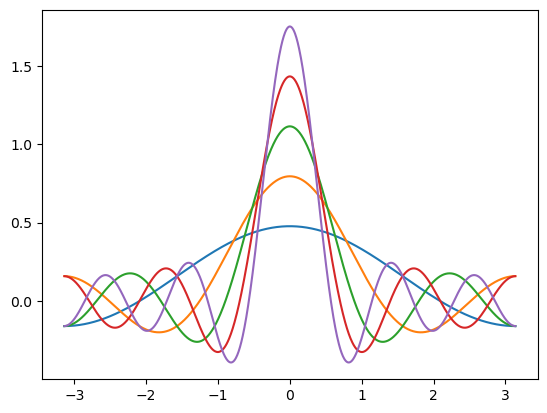

In [6]:
for _N in range(1, 6, 1):
    D = D_p(y/theta, _N)
    plt.plot(y, D)
plt.show()

In [7]:
def rho(x, c=1):
    r = np.exp(c*x**2/(x**2-np.pi**2))
    r[x<-np.pi] = 0
    r[x>np.pi] = 0
    return r

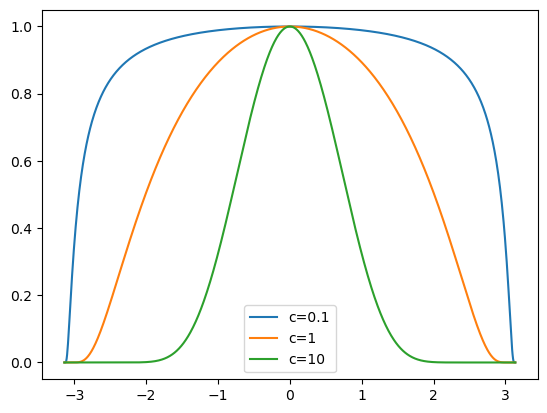

In [8]:
for _c in [.1, 1, 10]:
    rho_1 = rho(y/theta, c=_c)
    plt.plot(y, rho_1, label="c="+str(_c))
plt.legend()
plt.show()

In [9]:
# T = 1
# n = 100
# dx = T/n
# x = np.linspace(-T/2, T/2, n, endpoint=False)+dx/2
# print(x)
# y = np.arange(-T/2, T/2, dx)+dx/2
# print(y)
# np.allclose(x, y)

In [10]:
def phi(theta, c, N, dx):
    T = theta * (2*np.pi)
    #y = np.arange(-T/2, T/2, dx) + dx/2
    n = T/dx
    print(n, int(round(n)))
    y = np.linspace(-T/2, T/2, int(round(n)), endpoint=False)+dx/2
    return y, 1/theta * rho(y/theta, c=c) * D_p(y/theta, N=N)

999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000


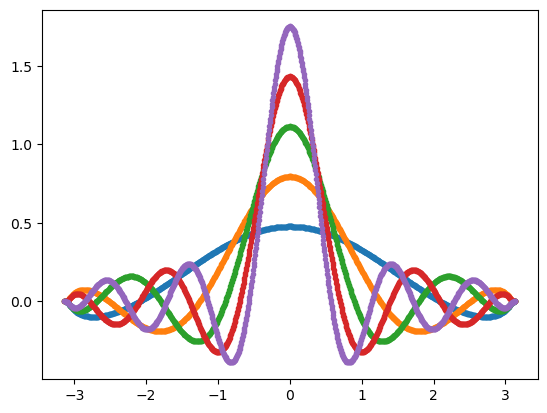

999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000


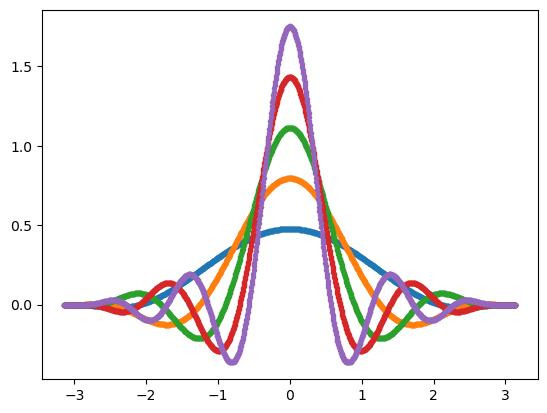

999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000
999.9999999999999 1000


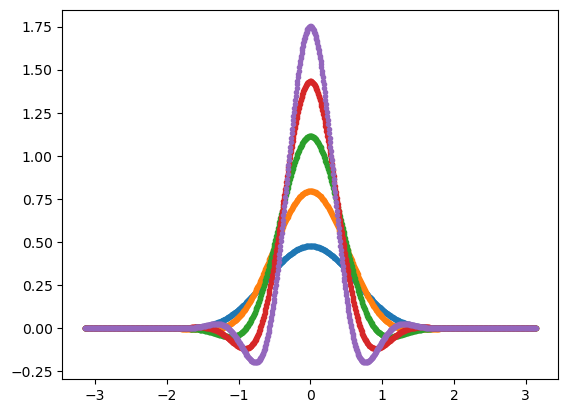

In [11]:

for _c in [.1, 1, 10]:
    for _N in range(1, 6):
       # phi = 1/theta * rho(x/theta, c=c) * D_p(x/theta, N=N)
        y, p = phi(theta, _c, _N, dx)
        plt.plot(y, p, marker=".", lw=.2)
    plt.show()

200.0 200


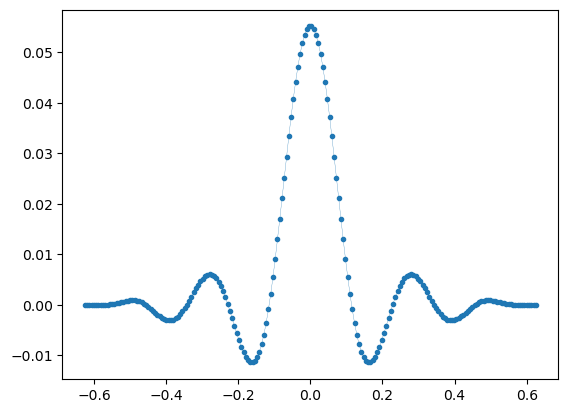

In [12]:
#x, p = phi(c=1, N=5)
y, g0 = phi(theta=.2, c=c, N=N, dx=dx)
g0 = g0/ np.sum(g0)
plt.plot(y, g0, marker=".", lw=.2)
plt.show()

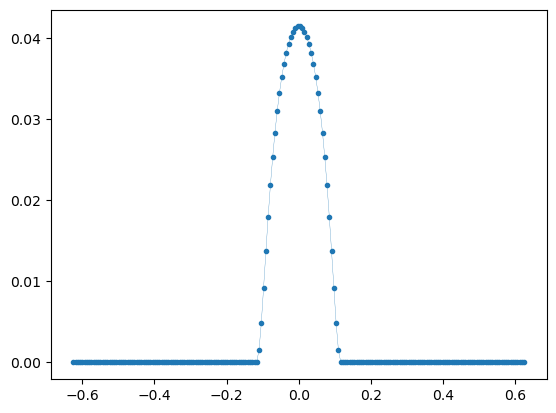

In [13]:
g4 = rho(y/0.04, c=1)
g4 = g4/ np.sum(g4)

plt.plot(y, g4, marker=".", lw=.2)
plt.show()

In [14]:
def gaussian(x, sigma, shift=True):
    dx = x[1]-x[0]
    if shift:
        x_kernel = fftshift(x)
        offset = x_kernel[0]
    else:
        x_kernel = x
        #offset = np.min(np.abs(x))  # or 0?
        offset = 0
    A = dx/(sigma*(2*np.pi)**.5)
    return A * np.exp(-(x_kernel-offset)**2 / (2 * sigma**2))

1.0 1.0000000000000087 0.9999999999999999 1.0000000000000002


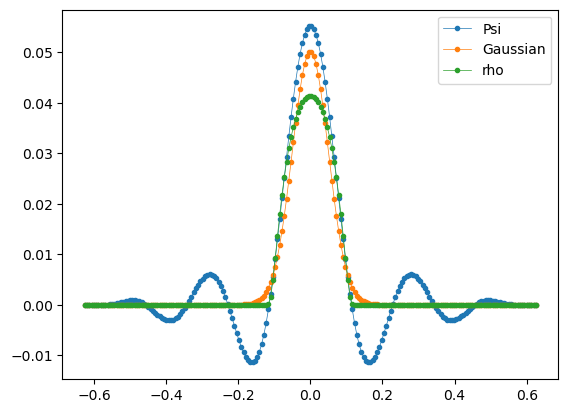

In [15]:
g1 = signal.gaussian(len(y), std=.05/dx)
g1 = g1 / np.sum(g1)
g2 = gaussian(y, sigma=.05, shift=False)
g3 = cv2.getGaussianKernel(len(y), .05/dx)

print(np.sum(g1), np.sum(g2), np.sum(g3), np.sum(g0))

plt.plot(y, g0, "C0.-", lw=.5, label="Psi")
plt.plot(y, g1, "C1.-", lw=.5, label="Gaussian")
plt.plot(y, g4, "C2.-", lw=.5, label="rho")
plt.legend()
# plt.plot(y, g2, "C1x")
# plt.plot(y, g3, "C2")
#plt.xlim(-.02, .02)
#plt.ylim(.045, .051)


In [16]:
X = np.empty((m, n))
Xs1 = np.empty((m, n))
Xs2 = np.empty((m, n))
Xs3 = np.empty((m, n))
Xs4 = np.empty((m, n))
for j in range(n):
    mu = mus[j]
    X[:, j] = g = f1(x, mu)
    sigma = 0.05
    #Xs1[:, j] = gaussian_filter1d(g, sigma=sigma/dx, mode="wrap")  
    Xs2[:, j] = ndimage.convolve1d(g, g0, mode="wrap")
    Xs3[:, j] = ndimage.convolve1d(g, g1, mode="wrap")
    Xs4[:, j] = ndimage.convolve1d(g, g4, mode="wrap")

(0.35, 0.45)

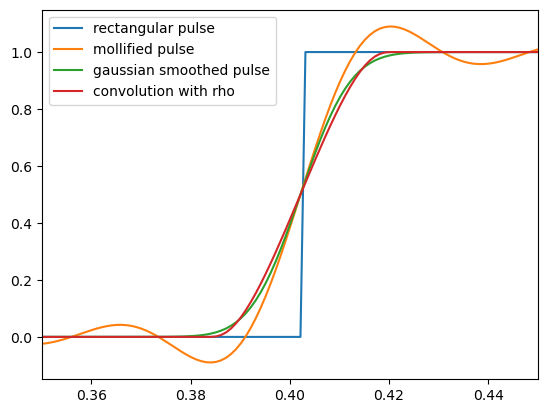

In [17]:
j = 500
plt.plot(x, X[:, j], label="rectangular pulse")
#plt.plot(x, Xs1[:, j])
plt.plot(x, Xs2[:, j], label="mollified pulse")
plt.plot(x, Xs3[:, j], label="gaussian smoothed pulse")
plt.plot(x, Xs4[:, j], label="convolution with rho")
plt.legend()
#plt.show()
plt.xlim(.35, .45)

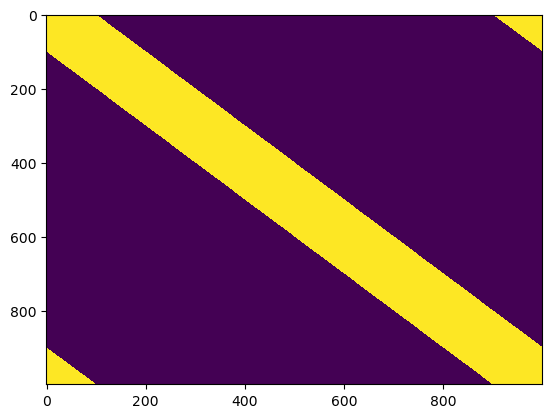

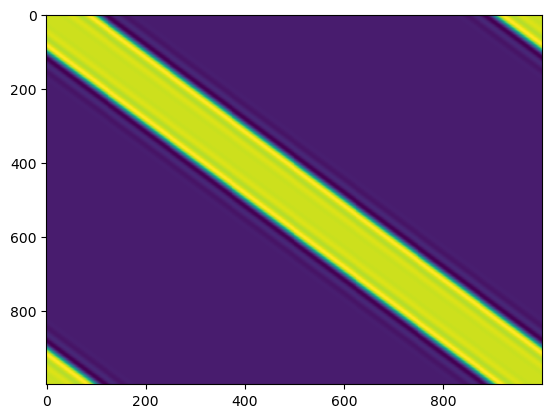

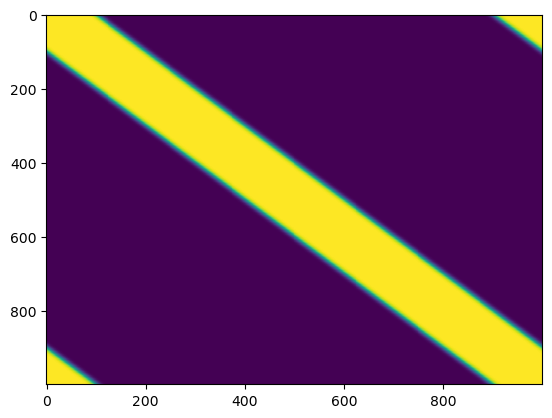

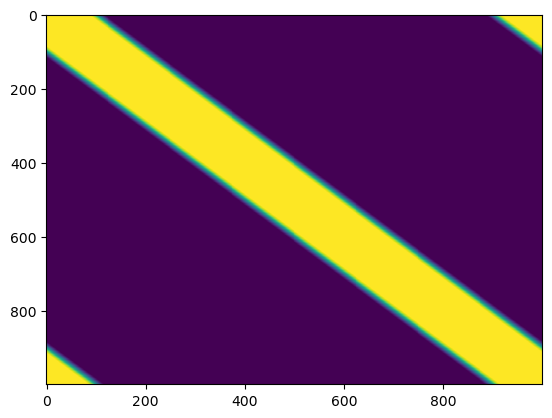

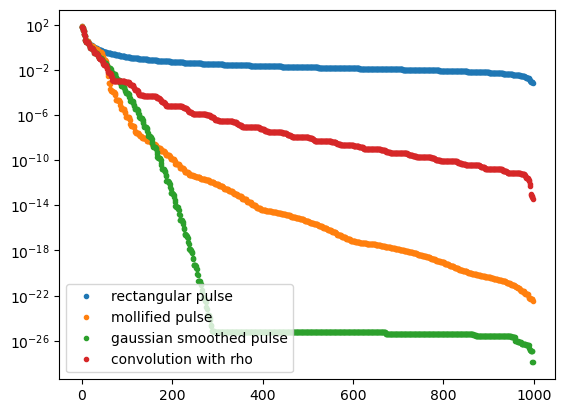

In [18]:

U = get_trig_basis(x, M=m//2)  # m, r
delta_ns = []
for Xs in [X, Xs2, Xs3, Xs4]:
    SVT = U.T@Xs  # r, n
    
    S = np.sum(SVT**2, axis=1)
    
    #U, S, VT = np.linalg.svd(Xs, full_matrices=False)
    delta_n = (np.cumsum(S[::-1]**2)[::-1]/m/n)**.5
    delta_ns.append(delta_n)
    plt.figure()
    plt.imshow(Xs, interpolation="nearest")
    plt.gca().set_aspect("auto")
    plt.show()


plt.plot(delta_ns[0], "C0.", label="rectangular pulse")
plt.plot(delta_ns[1], "C1.", label="mollified pulse")
plt.plot(delta_ns[2], "C2.", label="gaussian smoothed pulse")
plt.plot(delta_ns[3], "C3.", label="convolution with rho")
#plt.plot(1000/np.arange(len(S)), "C1.")
plt.gca().set_yscale("log")
plt.legend()
plt.show()




In [19]:
np.allclose(np.exp(1*x**2/(x**2-np.pi**2)), np.exp(-1/(1-(x/np.pi)**2)) * np.e)
np.allclose(np.exp(1*x**2/(x**2-np.pi**2)), np.exp(-1/(1-(x/np.pi)**2)+1))
np.allclose(1*x**2/(x**2-np.pi**2), -1/(1-(x/np.pi)**2)+1)
np.allclose(x**2/(x**2-np.pi**2), -1/(1-x**2/np.pi**2) + 1)
np.allclose(x**2/(x**2-np.pi**2), -1/(1-x**2/np.pi**2) + (1-x**2/np.pi**2)/(1-x**2/np.pi**2))
np.allclose(x**2/(x**2-np.pi**2), (-x**2/np.pi**2)/(1-x**2/np.pi**2))
np.allclose(x**2/(x**2-np.pi**2), (-x**2)/(np.pi**2-x**2))

True

https://en.wikipedia.org/wiki/Fej%C3%A9r_kernel
    